# Option Pricer: Binomial Tree, Monte Carlo, and Black-Scholes

This notebook demonstrates three pricing engines for European and American vanilla options, implemented in the `pricing/` package:

- **Binomial tree** (`pricing.binomial_tree`) - recombining Cox-Ross-Rubinstein (CRR) tree, European & American, with finite-difference Greeks.
- **Monte Carlo** (`pricing.monte_carlo`) - simulate risk-neutral geometric Brownian motion paths, average discounted payoffs, and estimate Greeks by bump-and-reprice.
- **Black-Scholes** (`pricing.black_scholes`) - closed-form price, Greeks, and Newton-Raphson implied volatility, used here as a benchmark for the other two.

**Contents**
1. Setup
2. CRR up/down factors and risk-neutral probability
3. Recursive tree pricer (European & American, call & put)
4. Example: European call
5. Example: American put (Hull textbook example)
6. Greeks via finite differences
7. Monte Carlo pricer
8. Black-Scholes benchmark, convergence, and implied volatility


## 1. Setup

All pricing functions now live in the `pricing` package (`pricing/binomial_tree.py`, `pricing/monte_carlo.py`, `pricing/black_scholes.py`) in the repo root. This notebook imports them and focuses on running scenarios, comparing methods, and plotting results.

In [1]:
import sys
sys.path.append("..")  # so `pricing` (in the repo root) is importable from notebooks/

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from pricing import (
    get_up_down_proba, PriceOptions, calculate_Greeks,
    get_brownian_motion_samples, get_geometric_brownian_motion,
    get_option_price_MC, get_delta_MC, get_gamma_MC, get_vega_MC, get_rho_MC,
    BlackScholes, get_delta_BS, get_gamma_BS, get_vega_BS, get_rho_BS, GetImpliedVolatility,
)


## 2. CRR up/down factors and risk-neutral probability

Given annualized volatility $\sigma$, step length $\Delta t$ (in years), and continuously-compounded risk-free rate $r$, the standard CRR parameterization is:

$$u = e^{\sigma\sqrt{\Delta t}}, \qquad d = e^{-\sigma\sqrt{\Delta t}}, \qquad p = \frac{e^{r\Delta t} - d}{u - d}$$

`p` is the risk-neutral probability of an up move; `1-p` is the probability of a down move.

## 3. Recursive tree pricer

`PriceOptions` walks the tree recursively and memoizes every node's value in the `prices` array so each `(step, position)` pair is only computed once. `position` is the net number of up-moves minus down-moves so far, ranging from `-step` to `+step`; it's stored at column index `position + n` so it always fits in a `2n+1`-wide row.

- `call = 1` for a call, `call = -1` for a put (via the shared payoff formula `max(call * (stock - strike), 0)`).
- `american = 1` allows early exercise: at every node the continuation value is compared against the intrinsic value and the larger of the two is kept. `american = 0` (default) prices a European option.


## 4. Example: European call

A 2-step tree for a European call, with `up`/`down`/`p` derived from volatility via `get_up_down_proba` (instead of recomputing the same formula by hand, as the original notebook did).

In [2]:
# --- Scenario 1: European call, 2 steps ---
n = 100
stock = 78.0
strike = 80.0
volatility = 0.3
riskFree = 0.03
T= 0.33
period = T/n  # length of ONE step, in years

up, down, p = get_up_down_proba(volatility, period, riskFree)

prices = np.full((n + 1, 2 * n + 1), -1, dtype=np.float64)
call_price = PriceOptions(prices, 0, 0, n, stock, strike, up, down, p, riskFree, period)
call_price


np.float64(4.820571913449532)

## 5. Example: American put (Hull textbook example)

S=40, K=42, u=1.1, d=0.9, r=12%, T=0.75 years, n=3 steps. Here `up`/`down` are given directly (not derived from a volatility), which is a valid way to build a CRR-style tree, but note this means the Greeks helper in Section 6 (which reverse-derives `up`/`down` from volatility) isn't directly applicable to this tree - see the note there.

In [3]:
# --- Scenario 2: American put, 3 steps ---
volatility = 0.25
riskFree = 0.12
period = 0.25
n = 3
up = 1.1
down = 0.9
p = (math.exp(riskFree * period) - down) / (up - down)

prices_put = np.full((n + 1, 2 * n + 1), -1, dtype=np.float64)
put_price = PriceOptions(prices_put, 0, 0, n, 40, 42, up, down, p, riskFree, period, call=-1, american=1)
put_price


np.float64(2.5373533380173767)

Full node-value grid for the American put tree. Row `step` holds columns `position + n` for `position` in `{-step, ..., step}` (same-parity positions only; the rest stay at the `-1` placeholder).

## 6. Calculating Greeks

`calculate_Greeks` estimates delta, gamma, vega, and rho from a *fully populated* tree (`tree_array`), using standard binomial-tree finite-difference formulas:

- **Delta** and **gamma** are read straight off neighboring nodes in the tree that's already been built (no re-pricing needed).
- **Vega** and **rho** are estimated by bumping volatility (or the rate) by 1% and re-pricing a *fresh* tree with `PriceOptions`, then taking the finite difference against the original price.

**Fixes applied vs. the original version of this function:**
1. `get_up_down_proba` requires a `riskFree` argument; the original call omitted it and raised a `TypeError`.
2. The original reused the name `n` for `len(tree_array)`, which equals `n_steps + 1` (the tree has `n_steps + 1` rows), not `n_steps`. That off-by-one silently corrupted every column lookup (delta came out as `0.0` instead of a real value). Fixed by using `n_steps = tree_array.shape[0] - 1` and indexing with `n_steps` throughout.
3. The vega/rho re-pricing calls passed total maturity `T` as the per-step `period` argument to `PriceOptions`, which expects the length of *one* step. Fixed by passing `dt = T / n_steps`.
4. For rho, only `r` was bumped but `p` depends on `r` too (`p = (exp(r*dt) - d) / (u - d)`) while `up`/`down` don't. The original reused the stale `p` computed at the original rate. Fixed by recalculating `p` at the bumped rate before re-pricing.

**Caveat:** this function assumes the tree it's handed was built with CRR `up`/`down` derived from `volatility` via `get_up_down_proba` (as in Scenario 1). If a tree was built from hand-picked `up`/`down` values (as in Scenario 2), the `up`/`down` this function re-derives from volatility won't match the tree's actual node spacing, and the Greeks will be wrong.

### Demo: Greeks for the Scenario 1 European call

We reuse the `prices` tree from Section 4, which was built with `up`/`down` from `get_up_down_proba`, so it satisfies the caveat above.

In [4]:
params = {
    'Volatility': 0.3,
    'Period': 2 * 0.1666666,  # total maturity = n_steps * period-per-step
    'StockPrice': 78.0,
    'StrikePrice': 80.0,
    'RiskFreeRate': 0.03,
    'Call': 1,
    'American': 0,
}

greeks = calculate_Greeks(prices, params)
greeks


{'delta': np.float64(0.49602084327994567),
 'gamma': np.float64(0.029452025786682476),
 'vega': np.float64(21.171223939640704),
 'rho': np.float64(14.504287730378174)}

## 7. Monte Carlo pricer

The binomial tree above prices options by building a discrete lattice of stock prices. An alternative approach is **Monte Carlo (MC) simulation**: simulate many random paths of the underlying stock price under the risk-neutral measure, compute the option's payoff on each path, average the payoffs, and discount back to today.

$$\text{Price} = e^{-rT} \, \mathbb{E}^{\mathbb{Q}}\big[\text{payoff}(S_T)\big] \approx e^{-rT} \cdot \frac{1}{M}\sum_{i=1}^{M} \text{payoff}(S_T^{(i)})$$

where $M$ is the number of simulated paths.

**A note on the previous version of this section:** it had several bugs that are fixed below:
1. `np.random.normal(0, dt, ...)` used `dt` as the standard deviation. The standard deviation of a Brownian increment over a step of length `dt` is `sqrt(dt)`, not `dt` itself (variance scales with `dt`, not std). This made simulated paths far too smooth, especially with many small steps.
2. `get_option_price_MC` only priced calls; there was no put payoff.
3. `get_delta_MC` was missing its `sigma` parameter and called `get_option_price_MC` with the wrong number of arguments, which raises a `TypeError` before it even gets to computing anything.
4. `get_gamma_MC` called `get_delta_MC` with an extra `sigma` argument that `get_delta_MC` (as previously written) didn't accept - same kind of crash.
5. `get_vega_MC` / `get_rho_MC` didn't take `sigma` as a parameter at all; they only worked because they happened to read a global `sigma` variable left over from an earlier cell. That's fragile - reassign `sigma` anywhere else in the notebook and these silently return the wrong number.
6. None of these functions were ever actually executed anywhere in the notebook, which is presumably how the bugs above went unnoticed.

The rewritten version below gives every function an explicit, consistent signature `(riskFree, sigma, Strike, Spot, n, M, T)`, supports both calls and puts via the same `call` flag used in `PriceOptions`, and is exercised with worked examples that cross-check against the binomial/closed-form price.

### 7.1 Simulating paths

`get_brownian_motion_samples` builds `M` sample paths of a standard Brownian motion $W_t$ over `[0, T]` with `n` steps. `get_geometric_brownian_motion` builds `M` sample paths of a geometric Brownian motion (the standard lognormal stock-price model)

$$dS_t = \mu S_t\, dt + \sigma S_t\, dW_t \quad\Longrightarrow\quad S_{t+\Delta t} = S_t \cdot \exp\Big[\big(\mu - \tfrac{1}{2}\sigma^2\big)\Delta t + \sigma \sqrt{\Delta t}\, Z\Big], \quad Z \sim N(0,1)$$

For risk-neutral pricing we simulate under $\mathbb{Q}$, i.e. we set the drift $\mu = r$ (the risk-free rate).

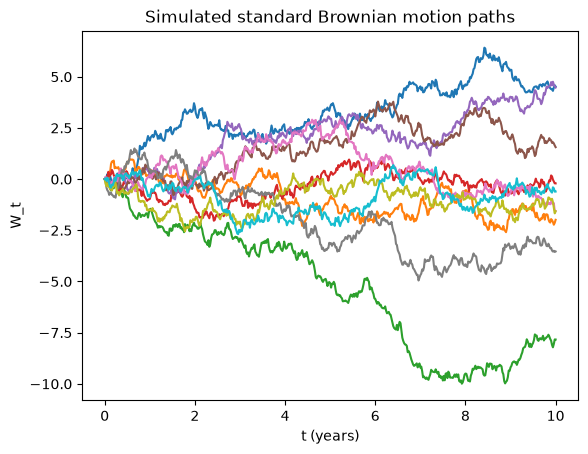

In [5]:
sigma_demo = 0.3
T_demo = 10
n_demo = 500
M_demo = 10

Brownian_motion = get_brownian_motion_samples(n_demo, sigma_demo, T_demo, M_demo)

time = np.linspace(0, T_demo, n_demo + 1)
plt.plot(time, Brownian_motion)
plt.title("Simulated standard Brownian motion paths")
plt.xlabel("t (years)")
plt.ylabel("W_t")
plt.show()


### 7.2 Pricing with Monte Carlo

`get_option_price_MC` now supports both calls and puts through the same `call` flag convention used by `PriceOptions` (`call=1` for a call, `call=-1` for a put), and returns the standard error of the price estimate alongside the price itself, since a MC price is only an estimate and it's useful to know how noisy it is.

**Example 1 - European call, cross-check against the binomial tree.**

Same parameters as Scenario 1 (Section 4): `stock=78`, `strike=80`, `volatility=0.3`, `riskFree=0.03`, and a total maturity of `2 * 0.1666666` years. We use a much finer time grid (`n=200`) and a large number of paths (`M=100,000`) for the MC estimate, since MC accuracy improves with more paths (error shrinks like $1/\sqrt{M}$) and, separately, with more time steps per path (which better approximates continuous-time GBM).

In [6]:
np.random.seed(0)  # for reproducibility of this demo

stock_ex = 78.0
strike_ex = 80.0
vol_ex = 0.3
r_ex = 0.03
T_ex = 2 * 0.1666666  # same total maturity as the binomial Scenario 1

mc_call_price, mc_call_stderr = get_option_price_MC(
    r_ex, vol_ex, strike_ex, stock_ex, n=200, M=100_000, T=T_ex, call=1
)

print(f"Binomial call price   : {call_price:.4f}")
print(f"Monte Carlo call price: {mc_call_price:.4f}  (+/- {1.96 * mc_call_stderr:.4f}, 95% CI)")


Binomial call price   : 4.8206
Monte Carlo call price: 4.8634  (+/- 0.0517, 95% CI)


**Example 2 - European put, same underlying/market parameters.**

Just flip `call=-1`. There's no closed-form/binomial put at these exact European parameters computed earlier in the notebook (Section 5's American put used different `u`/`d`/`r`/`T`), so as a sanity check we instead verify **put-call parity**:

$$C - P = S_0 - K e^{-rT}$$

which must hold for European options regardless of the pricing method.

In [8]:
mc_put_price, mc_put_stderr = get_option_price_MC(
    r_ex, vol_ex, strike_ex, stock_ex, n=200, M=100_000, T=T_ex, call=-1
)

parity_lhs = mc_call_price - mc_put_price
parity_rhs = stock_ex - strike_ex * math.exp(-r_ex * T_ex)

print(f"Monte Carlo put price : {mc_put_price:.4f}  (+/- {1.96 * mc_put_stderr:.4f}, 95% CI)")
print()
print(f"Put-call parity check:  C - P = {parity_lhs:.4f}")
print(f"                        S - Ke^(-rT) = {parity_rhs:.4f}")
print(f"                        difference = {abs(parity_lhs - parity_rhs):.4f}")


Monte Carlo put price : 6.0653  (+/- 0.0469, 95% CI)

Put-call parity check:  C - P = -1.2019
                        S - Ke^(-rT) = -1.2040
                        difference = 0.0021


### 7.3 Greeks via Monte Carlo (bump-and-reprice)

Same idea as Section 6's finite-difference Greeks, but using `get_option_price_MC` for every reprice instead of the tree. Every function below now takes an explicit `sigma` parameter and calls `get_option_price_MC` with the correct number of arguments in the correct order - the previous version's `get_delta_MC` and `get_gamma_MC` would raise a `TypeError` before computing anything, since they were missing `sigma` or mismatched arguments.

Because each bump requires an independent MC re-simulation, these Greeks are noisier than the tree-based ones (each call has its own MC sampling error). Using the same random seed before every call in a pair reduces that noise (common random numbers), since it makes the two price estimates move together except for the actual bump.

**Example - Greeks for the same European call as Example 1, compared against the tree-based Greeks from Section 6.**

These won't match to many decimal places (Monte Carlo has sampling error, especially for gamma which uses a second difference and amplifies noise), but they should be in the same ballpark.

In [9]:
mc_greeks = {
    'delta': get_delta_MC(r_ex, vol_ex, strike_ex, stock_ex, n=200, M=100_000, T=T_ex, call=1),
    'gamma': get_gamma_MC(r_ex, vol_ex, strike_ex, stock_ex, n=200, M=100_000, T=T_ex, call=1),
    'vega':  get_vega_MC(r_ex, vol_ex, strike_ex, stock_ex, n=200, M=100_000, T=T_ex, call=1),
    'rho':   get_rho_MC(r_ex, vol_ex, strike_ex, stock_ex, n=200, M=100_000, T=T_ex, call=1),
}

print("Tree-based Greeks (Section 6):")
for k, v in greeks.items():
    print(f"  {k:5s}: {v:.4f}")

print()
print("Monte Carlo Greeks:")
for k, v in mc_greeks.items():
    print(f"  {k:5s}: {v:.4f}")


Tree-based Greeks (Section 6):
  delta: 0.4960
  gamma: 0.0295
  vega : 21.1712
  rho  : 14.5043

Monte Carlo Greeks:
  delta: 0.5006
  gamma: 0.0293
  vega : 17.9032
  rho  : 11.4600


### 7.4 Convergence check

A quick illustration of why the previous `sigma`/`std` bug mattered, and why `M` (number of paths) needs to be reasonably large: as `M` grows, the Monte Carlo price should converge to the binomial price, with the 95% confidence interval shrinking roughly like $1/\sqrt{M}$.

In [10]:
path_counts = [100, 1_000, 10_000, 100_000]
print(f"{'M':>8s}  {'MC price':>10s}  {'95% CI width':>13s}")
for M_test in path_counts:
    np.random.seed(42)
    p, se = get_option_price_MC(r_ex, vol_ex, strike_ex, stock_ex, n=200, M=M_test, T=T_ex, call=1)
    print(f"{M_test:8d}  {p:10.4f}  {2*1.96*se:13.4f}")

print(f"\nBinomial price for comparison: {call_price:.4f}")


       M    MC price   95% CI width
     100      4.9018         2.9286
    1000      5.0278         1.0658
   10000      4.7326         0.3220
  100000      4.8195         0.1028

Binomial price for comparison: 4.8206


## 8. Black-Scholes benchmark, convergence, and implied volatility

As a closed-form benchmark, `pricing.black_scholes.BlackScholes` gives the exact European price under the Black-Scholes model. We use it to:

- check that the binomial tree price converges to it as the number of steps grows,
- back out implied volatility from a known price via `GetImpliedVolatility` (Newton-Raphson), and
- verify the round-trip (recovering `volatility` from `bsPrice`) for both a call and a put.

In [11]:
n = 500
stock = 78.0
strike = 80.0
volatility = 0.3
riskFree = 0.03
T= 0.33
period = T/n
bsPrice = BlackScholes(stock,volatility, strike, T,riskFree)
bsPrice

np.float64(4.813251377514966)

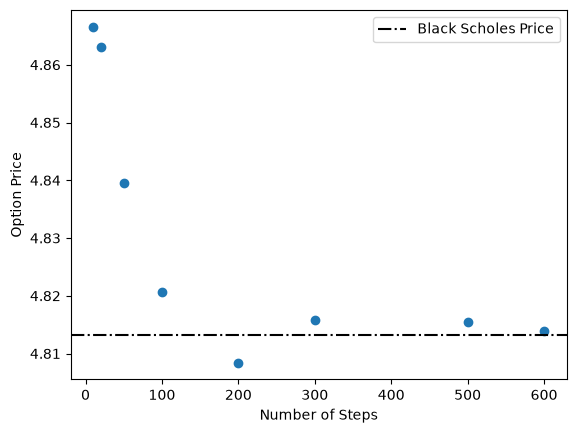

In [12]:
# --- Scenario 1: European call, 2 steps ---
nsteps = [10,20,50,100,200,300,500,600]
stock = 78.0
strike = 80.0
volatility = 0.3
riskFree = 0.03
T= 0.33

TreePrices = []
for n in nsteps:
  period = T/n
  up, down, p = get_up_down_proba(volatility, period, riskFree)
  prices = np.full((n + 1, 2 * n + 1), -1, dtype=np.float64)
  call_price = PriceOptions(prices, 0, 0, n, stock, strike, up, down, p, riskFree, period)
  TreePrices.append(call_price)
plt.scatter(nsteps,TreePrices)
plt.xlabel('Number of Steps')
plt.ylabel('Option Price')
plt.axhline(bsPrice, linestyle='dashdot', color='black', label = 'Black Scholes Price')
plt.legend()

In [13]:
G = GetImpliedVolatility(stock, strike, T, riskFree, bsPrice)
print(G)

0.30000000028131857


In [14]:
bsPut = BlackScholes(stock, volatility, strike, T,riskFree, 'P')
bsPut

np.float64(6.025158872151543)

In [15]:
GetImpliedVolatility(stock, strike, T, riskFree,bsPut,'P')

np.float64(0.3000000002813181)

In [17]:
bs_greeks = {
    'detla': get_delta_BS(stock, strike,volatility,T,riskFree),
    'gamma': get_gamma_BS(stock, strike,volatility,T,riskFree),
    'rho': get_rho_BS(stock, strike,volatility,T,riskFree),
    'vega': get_gamma_BS(stock, strike,volatility,T,riskFree),
}

In [18]:
bs_greeks

{'detla': np.float64(0.4986855848670104),
 'gamma': np.float64(0.029678017135542217),
 'rho': np.float64(11.247793999896908),
 'vega': np.float64(0.029678017135542217)}

In [19]:
!pip freeze > requirements.txt